In [1]:
import pandas as pd 
df = pd.read_csv('fakegprdata.csv')
print(df.head())

          x          y
0 -5.000000  11.328235
1 -4.949749  11.104013
2 -4.899497  10.902106
3 -4.849246  10.867776
4 -4.798995  10.473995


This was my first attempt at doing everything from memory. It was only about 20% from memory and the other parts from reference but only other script reference. The data points are too close together and too informative and so there is very little uncertainty. It doesnt match my final use case well so next I will use smaller less obvious dataset.

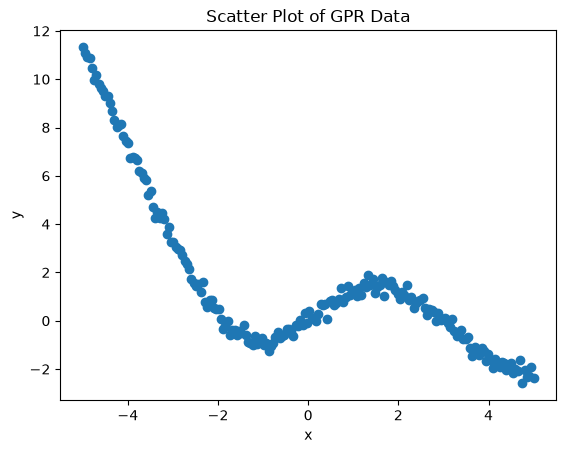

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of GPR Data')
plt.show()

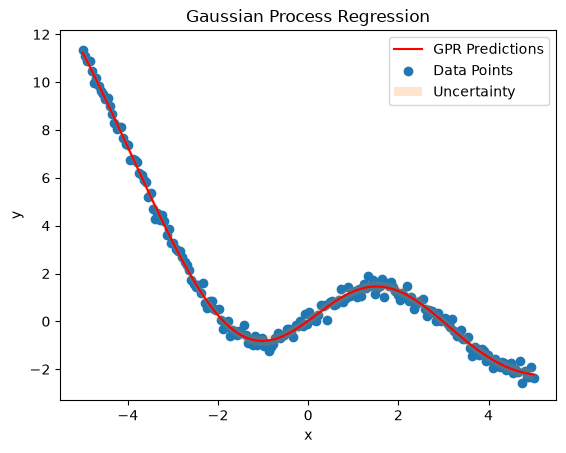

7.04**2 * RBF(length_scale=2.69) + WhiteKernel(noise_level=0.0421)

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor   
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(df[['x']], df['y'])
mean_predictions_gpr, std_predictions_gpr = gaussian_process.predict(df[['x']], return_std=True)

plt.plot(df['x'], mean_predictions_gpr, color='red', label='GPR Predictions')
plt.scatter(df['x'], df['y'], label='Data Points')
plt.fill_between(df['x'], mean_predictions_gpr - std_predictions_gpr, mean_predictions_gpr + std_predictions_gpr, alpha=0.2, label='Uncertainty')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussian Process Regression')
plt.legend()
plt.show()
gaussian_process.kernel_
